# Phase 3 — Index Validation, EDA & Risk Label Construction
**Project:** Jijiga Flood & Drought Risk Prediction (42.75°E, 9.25°N)  
ERA5 single grid-point, 2000–2025, daily resolution

This notebook covers three steps:

- **Data validation**: Load the daily ERA5 data and visually validate the four climate indices (SPEI-6/12, API, SMI) that were computed by the data pipeline
- **Exploratory data analysis**: Time series plots, distributions, correlation matrix, autocorrelation, and seasonal decomposition
- **Risk label construction**: Construct drought and flood risk labels from the validated indices, create forecast targets at four horizons (+1, +3, +7, +14 days), and spot-check against EM-DAT disaster records

The indices (SPEI-6, SPEI-12, API with k=0.92, SMI normalised by field capacity) are loaded directly from `src/data/processed/era5_final.parquet`. Phase 3 does not recompute them, but it validates that they behave physically correctly before using them as the basis for risk labels.

**Output:** `src/data/processed/era5_labeled.parquet` — read by Phase 4 for feature engineering.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf, adfuller
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

DATA_PATH  = '../src/data/processed/era5_final.parquet'
EMDAT_PATH = '../src/data/processed/emdat.xlsx'
OUT_PATH   = '../src/data/processed/era5_labeled.parquet'

TRAIN_END = 2022   # training/test cut; reference climatology uses ≤2020
CLIM_END  = 2020   # SPEI climatology reference period end

---
## Data validation & index computation

In [2]:
# ── Load & structural validation ──────────────────────────────────────────────
df = pd.read_parquet(DATA_PATH)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

expected_dates = pd.date_range('2000-01-01', '2025-12-31', freq='D')
actual_dates   = pd.DatetimeIndex(df['time'].values)
missing_dates  = expected_dates.difference(actual_dates)

print('Shape            :', df.shape)
print('Expected rows    :', len(expected_dates))
print('Date range       :', df.time.min().date(), '→', df.time.max().date())
print('Duplicate dates  :', df.time.duplicated().sum())
print('Missing dates    :', len(missing_dates))
print('Columns          :', df.columns.tolist())

# Guard: pipeline-computed index columns must be present
required_indices = ['api_92', 'smi_fc', 'spei_6', 'spei_12', 'total_ro']
missing_idx = [c for c in required_indices if c not in df.columns]
if missing_idx:
    raise RuntimeError(
        f"Missing pipeline-computed columns: {missing_idx}. "
        "Re-run src/run_pipeline.py to regenerate era5_2000_2025.parquet."
    )
print('Pipeline index columns present: OK')
df.head(3)

Shape            : (9497, 24)
Expected rows    : 9497
Date range       : 2000-01-01 → 2025-12-31
Duplicate dates  : 0
Missing dates    : 0
Columns          : ['longitude', 'latitude', 'time', 'number', 'u10', 'v10', 'd2m', 't2m', 'sp', 'swvl1', 'swvl2', 'tp', 'ssrd', 'e', 'pev', 'ssro', 'sro', 'lsp', 'vimd', 'total_ro', 'api_92', 'smi_fc', 'spei_6', 'spei_12']
Pipeline index columns present: OK


,longitude,latitude,time,number,u10,v10,d2m,t2m,sp,swvl1,...,pev,ssro,sro,lsp,vimd,total_ro,api_92,smi_fc,spei_6,spei_12
0,42.75,9.25,2000-01-01,0,0.149502,-2.109512,275.105652,291.637817,83424.28125,0.130697,...,-0.001027,0.0,0.0,0.0,0.747879,0.0,0.0,0.533461,NaN,NaN
1,42.75,9.25,2000-01-02,0,-0.917221,-1.640968,269.649170,291.135803,83389.43750,0.129396,...,-0.001067,0.0,0.0,0.0,0.276138,0.0,0.0,0.530600,NaN,NaN
2,42.75,9.25,2000-01-03,0,-1.146851,-1.342113,269.747864,290.856873,83389.90625,0.128496,...,-0.001065,0.0,0.0,0.0,0.266953,0.0,0.0,0.528922,NaN,NaN


SPEI-6  range: -4.753 → 0.858
SPEI-12 range: -4.753 → 0.78
NaNs SPEI-6 : 152   SPEI-12: 335


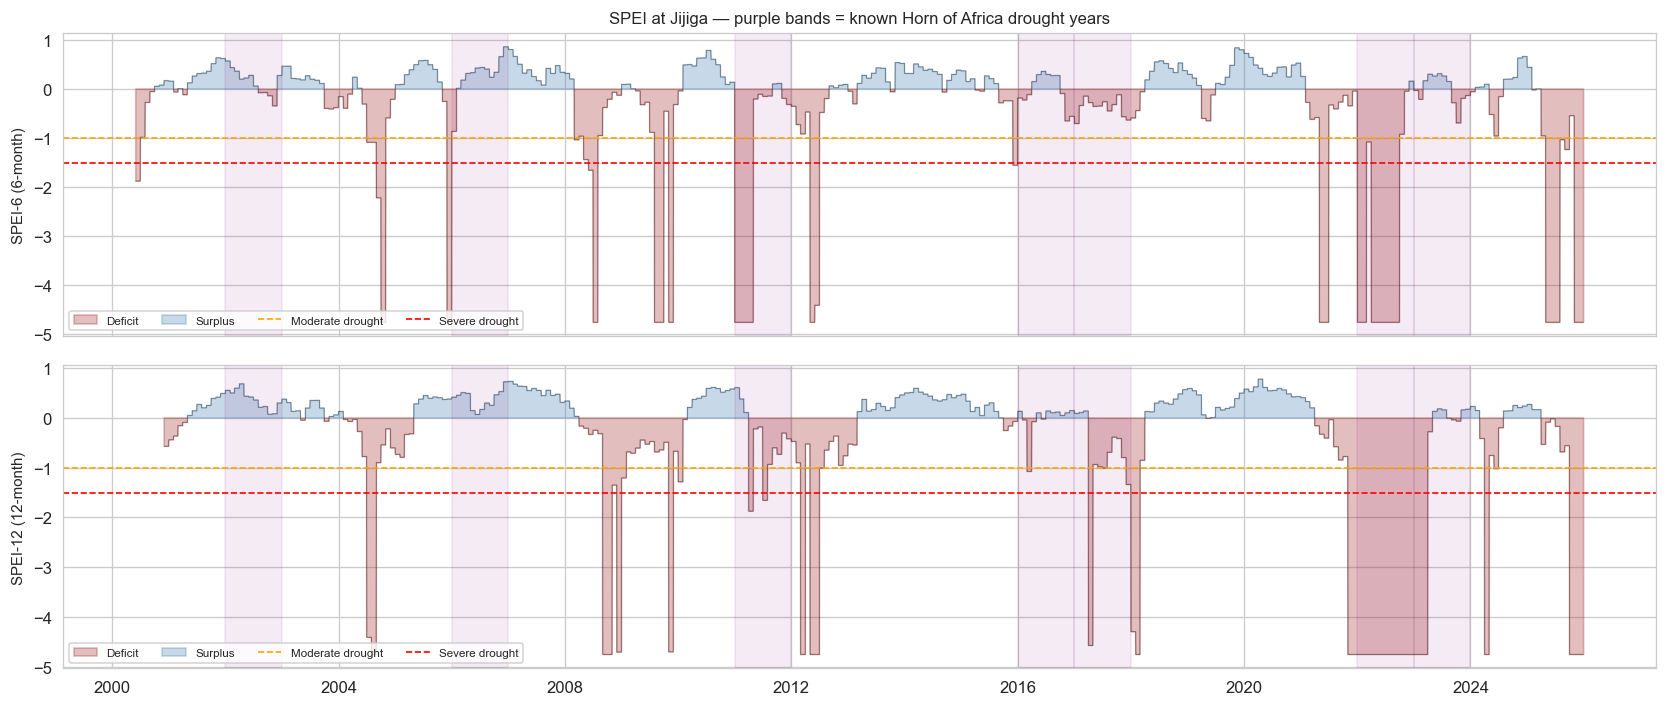

In [3]:
# ── Validate SPEI-6 and SPEI-12 (computed by pipeline, loaded from parquet) ───
print('SPEI-6  range:', round(df['spei_6'].min(), 3),  '→', round(df['spei_6'].max(), 3))
print('SPEI-12 range:', round(df['spei_12'].min(), 3), '→', round(df['spei_12'].max(), 3))
print('NaNs SPEI-6 :', df['spei_6'].isna().sum(), '  SPEI-12:', df['spei_12'].isna().sum())


known_droughts = [2002, 2006, 2011, 2016, 2017, 2022, 2023]
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax, col, label in zip(axes, ['spei_6', 'spei_12'], ['SPEI-6 (6-month)', 'SPEI-12 (12-month)']):
    s = df.set_index('time')[col].dropna()
    ax.fill_between(s.index, s.values, 0, where=s.values < 0, color='brown',  alpha=0.3, label='Deficit')
    ax.fill_between(s.index, s.values, 0, where=s.values >= 0, color='steelblue', alpha=0.3, label='Surplus')
    ax.plot(s.index, s.values, color='black', lw=0.4, alpha=0.5)
    ax.axhline(-1.0, color='orange', ls='--', lw=1, label='Moderate drought')
    ax.axhline(-1.5, color='red',    ls='--', lw=1, label='Severe drought')
    for yr in known_droughts:
        ax.axvspan(pd.Timestamp(yr, 1, 1), pd.Timestamp(yr, 12, 31),
                   alpha=0.08, color='purple', label='_nolegend_')
    ax.set_ylabel(label, fontsize=9)
    ax.legend(fontsize=7, ncol=4, loc='lower left')
axes[0].set_title('SPEI at Jijiga — purple bands = known Horn of Africa drought years', fontsize=10)
plt.tight_layout()
plt.savefig('phase3_spei.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure - SPEI-6 and SPEI-12 at Jijiga (2000–2025)**

This figure shows two versions of the SPEI drought index over 25 years. Blue shading means there was more precipitation than normal, brown shading means a deficit. The two dashed lines mark the thresholds for moderate (−1.0) and severe (−1.5) drought conditions.

The purple bands mark well-known drought years from the literature. They were not derived from the data itself, but added manually as an independent reference. The purpose is to check whether the index responds correctly: if SPEI drops during a purple band, the calculation is working as intended.

This holds for almost all known drought years, with 2011 as the deepest trough. The exception is 2016–2017, where SPEI barely drops despite being a documented drought year. This points to a limitation of the single grid-point approach: the drought was more severe elsewhere in the region than at this specific coordinate.

The difference between the two panels: SPEI-6 reacts faster to a single failed rainy season, while SPEI-12 only responds after multiple consecutive seasons fall short. Both are correct: they measure the same phenomenon at different timescales.

API-92  range: 0.000000 → 0.020178
SMI-FC  range: 0.4381 → 1.0000
total_ro range: 0.000000 → 0.002018


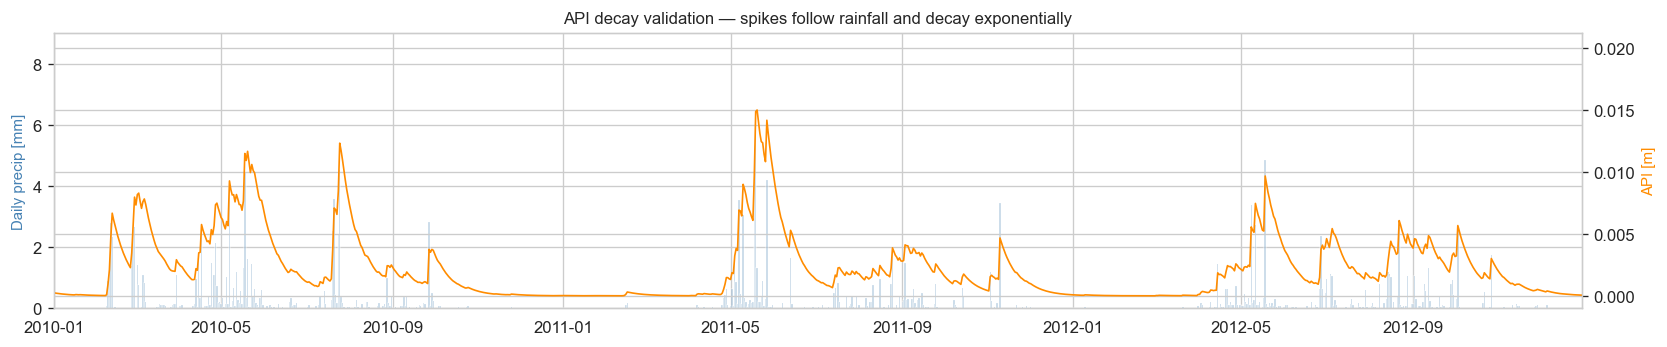

In [4]:
# ── Validate API (k=0.92) and SMI (field-capacity) — loaded from pipeline ─────
print(f'API-92  range: {df.api_92.min():.6f} → {df.api_92.max():.6f}')
print(f'SMI-FC  range: {df.smi_fc.min():.4f} → {df.smi_fc.max():.4f}')
print(f'total_ro range: {df.total_ro.min():.6f} → {df.total_ro.max():.6f}')

fig, ax = plt.subplots(figsize=(14, 3))
ax2 = ax.twinx()
ax.bar(df['time'], df['tp'] * 1000, color='steelblue', alpha=0.4, width=1, label='tp [mm]')
ax2.plot(df['time'], df['api_92'], color='darkorange', lw=1, label='API (k=0.92)')
ax.set_ylabel('Daily precip [mm]', color='steelblue', fontsize=9)
ax2.set_ylabel('API [m]', color='darkorange', fontsize=9)
ax.set_title('API decay validation — spikes follow rainfall and decay exponentially', fontsize=10)
ax.set_xlim(pd.Timestamp('2010-01-01'), pd.Timestamp('2012-12-31'))
plt.tight_layout()
plt.show()

**Figure - API validation (2010–2012 excerpt).**

This figure validates that the Antecedent Precipitation Index (API) behaves correctly. The blue bars show daily precipitation and the orange line shows the resulting API value.

Two things should be visible: API spikes immediately after rainfall, and then decays exponentially during dry periods. Both of these things are confirmed here. This exponential decay reflects how quickly soil moisture dissipates through drainage and evaporation in the semi-arid Somali Region, with a decay constant of k=0.92, a rainfall event loses roughly half its weight after about 12 days.

The 2010–2011 period shows this clearly: after peaks in May and August 2010, API drops to near zero and stays there from September 2010 through April 2011, a dry stretch of roughly eight months. This aligns with the 2011 drought, where reduced and delayed rainfall meant API never had the chance to recover to normal seasonal levels. The same spike-and-decay pattern repeats in 2011 and 2012, confirming that the behaviour is consistent across years and not an artefact of a specific period.

---
## Exploratory Data Analysis

In [5]:
# ── Load EMDAT events ─────────────────────────────────────────────────────────
emdat = pd.read_excel(EMDAT_PATH)
eth   = emdat[emdat['ISO'] == 'ETH'].copy()

def to_date(row, prefix):
    try:
        yr = int(row[f'{prefix} Year'])
        mo = int(row.get(f'{prefix} Month') or 1)
        dy = int(row.get(f'{prefix} Day')   or 1)
        return pd.Timestamp(yr, mo, dy)
    except Exception:
        return pd.NaT

for dis_type in ['Flood', 'Drought']:
    sub = eth[eth['Disaster Type'] == dis_type].copy()
    sub['start_date'] = sub.apply(to_date, prefix='Start', axis=1)
    sub['end_date']   = sub.apply(to_date, prefix='End',   axis=1)
    sub = sub[sub['Start Year'].between(2000, 2025)].dropna(subset=['start_date'])
    if dis_type == 'Flood':
        eth_flood   = sub
    else:
        eth_drought = sub

print(f'ETH flood events   : {len(eth_flood)}')
print(f'ETH drought events : {len(eth_drought)}')

ETH flood events   : 31
ETH drought events : 0


EM-DAT flood events for Ethiopia are loaded here as an independent reference. They are used purely for visual annotation in the plots below, never as training labels or model input.

Note: EM-DAT returns 0 documented drought events for Ethiopia in this period. This is a known limitation of the database: droughts are systematically underreported due to their gradual onset and lack of a clear start date. Drought validation is therefore done using known years from the literature instead.



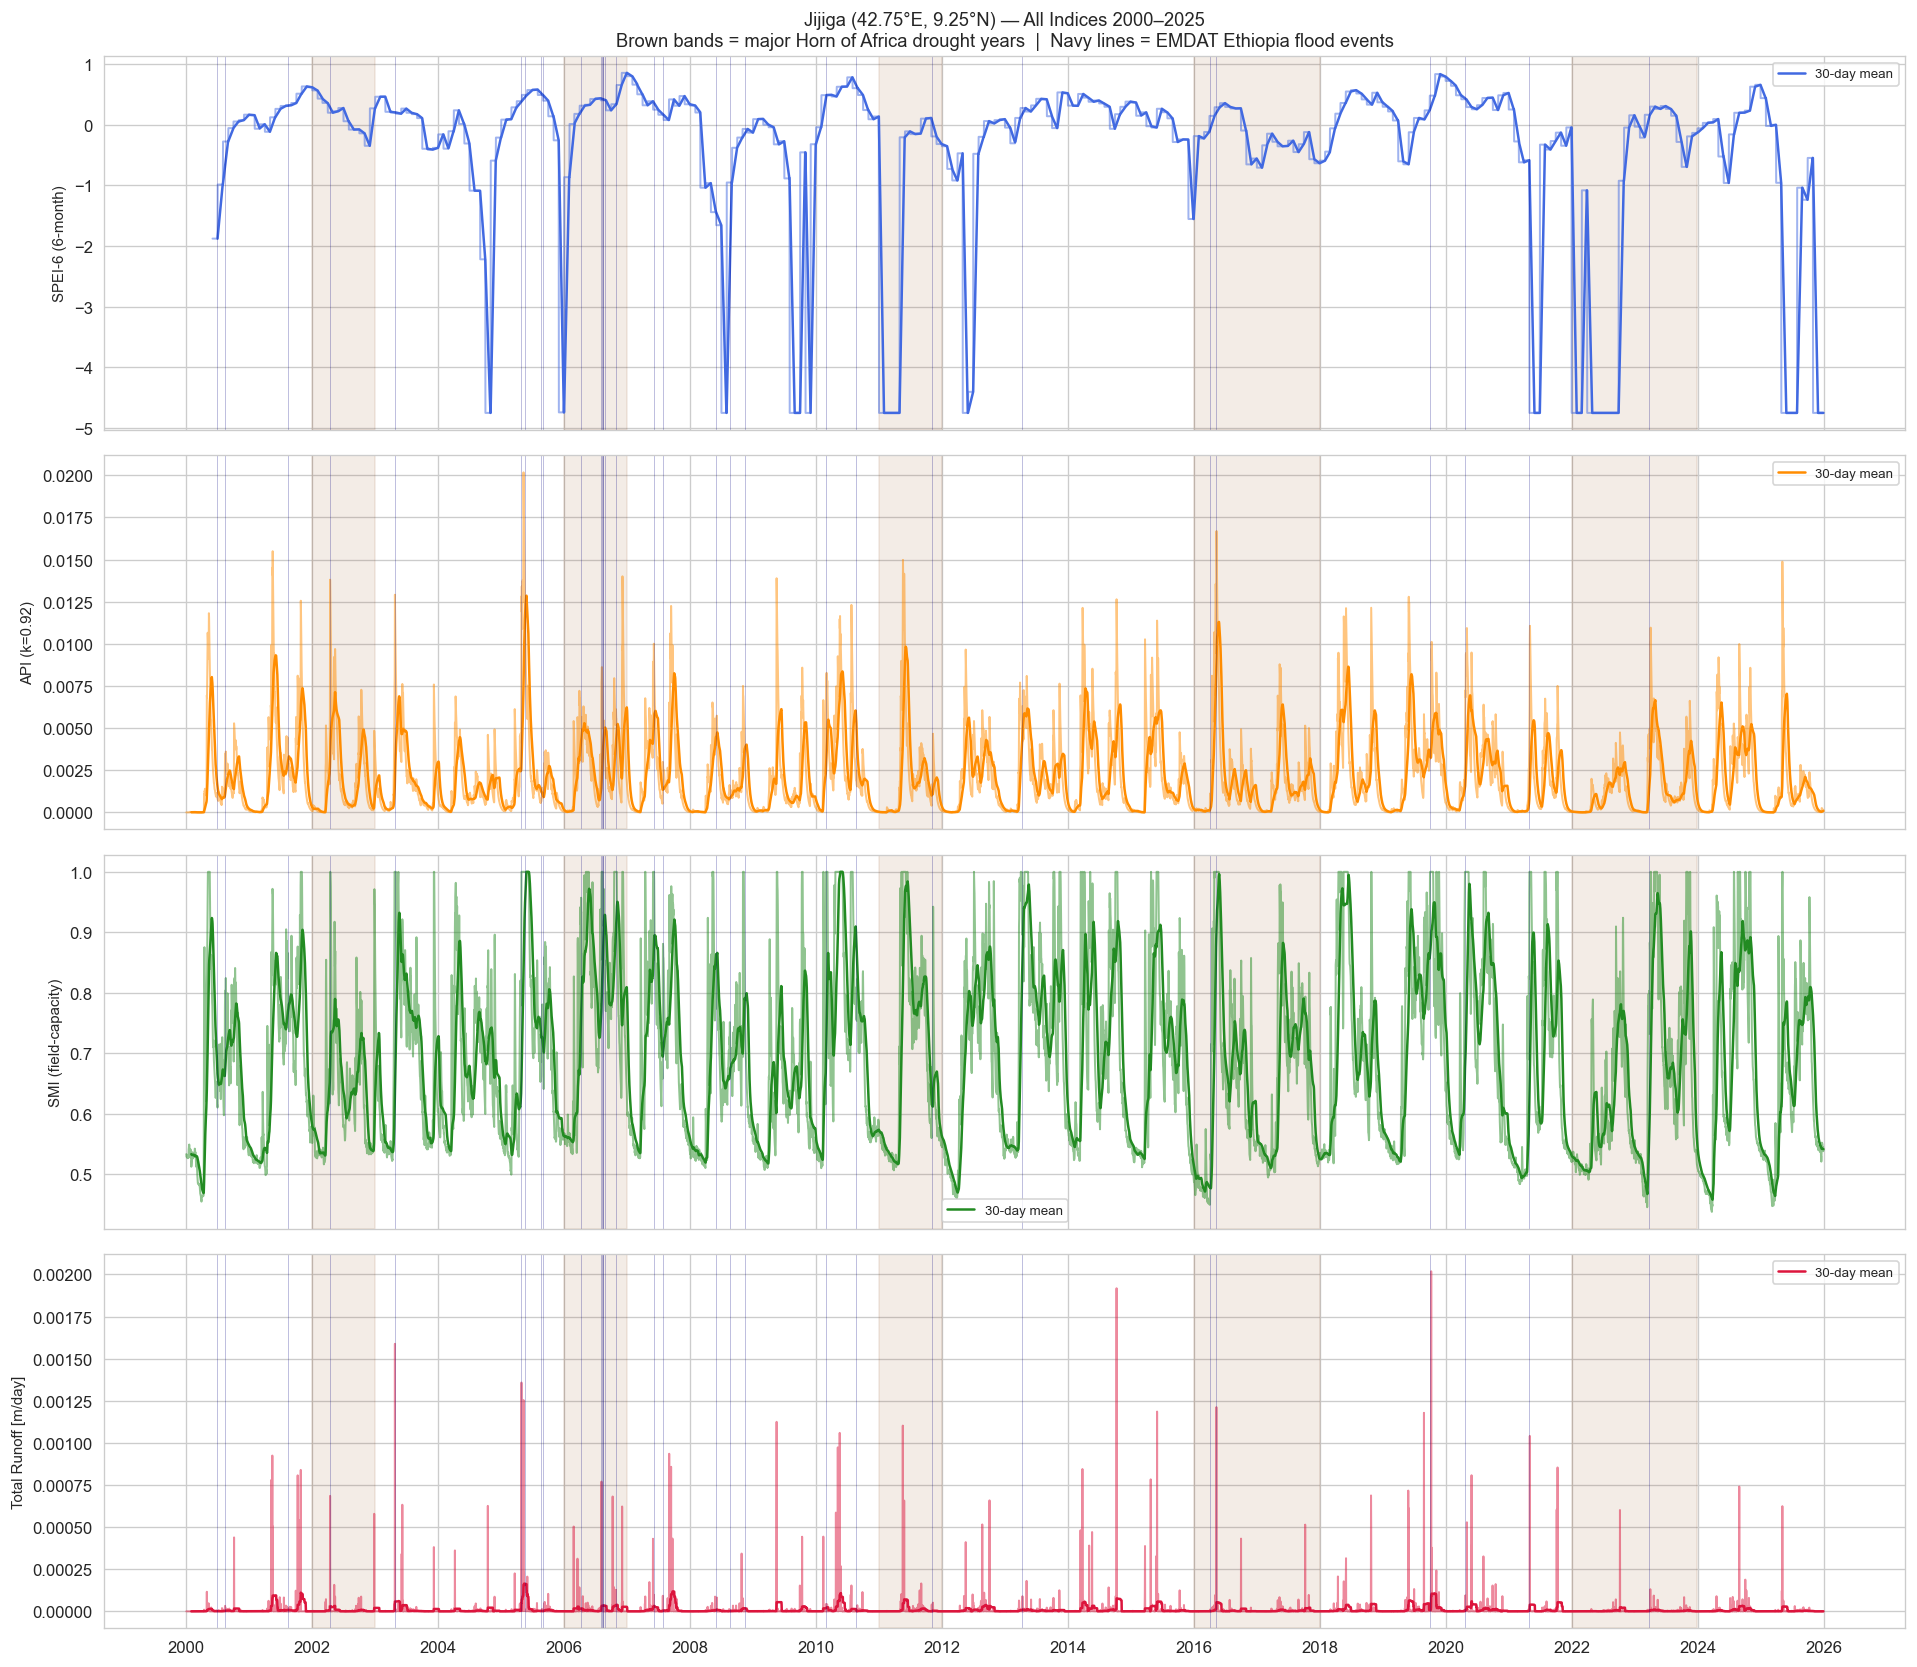

In [6]:
# ── P1: Full EDA — 4-panel time series with EMDAT annotations ─────────────────
DROUGHT_BANDS = [(2002,2002),(2006,2006),(2011,2011),(2016,2017),(2022,2023)]

df_idx = df.set_index('time')
indices = [
    ('spei_6',   'SPEI-6 (6-month)',      'royalblue'),
    ('api_92',   'API (k=0.92)',           'darkorange'),
    ('smi_fc',   'SMI (field-capacity)',   'forestgreen'),
    ('total_ro', 'Total Runoff [m/day]',   'crimson'),
]

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

for ax, (col, label, color) in zip(axes, indices):
    s = df_idx[col].dropna()
    ax.plot(s.index, s.values, color=color, alpha=0.5, lw=1.2)
    rm = s.rolling(30).mean()
    ax.plot(rm.index, rm.values, color=color, lw=1.5, label='30-day mean')
    ax.set_ylabel(label, fontsize=9)
    for y0, y1 in DROUGHT_BANDS:
        ax.axvspan(pd.Timestamp(y0, 1, 1), pd.Timestamp(y1, 12, 31),
                   alpha=0.10, color='saddlebrown')
    for _, row in eth_flood.iterrows():
        ax.axvline(row['start_date'], color='navy', alpha=0.25, lw=0.6)
    ax.legend(fontsize=8)

axes[0].set_title(
    'Jijiga (42.75°E, 9.25°N) — All Indices 2000–2025\n'
    'Brown bands = major Horn of Africa drought years  |  Navy lines = EMDAT Ethiopia flood events',
    fontsize=11
)
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('phase3_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure - Full 25-year time series of all four indices at Jijiga (2000–2025).**

This figure shows all four indices over the full 25-year record. The faint line is the raw daily value, the bold line is a 30-day rolling mean. Brown bands mark known drought years from the literature, navy lines mark EM-DAT flood event start dates for Ethiopia.

The main purpose is to verify that all four indices respond to events we know happened. If an index showed no reaction at all, that would indicate a problem with the data or the computation.

**SPEI-6** - SPEI-6 measures the six-month cumulative water balance standardised against the historical norm. Positive values indicate wetter than normal conditions, negative values indicate drier than normal.

At this semi-arid location, SPEI regularly drops to extreme negative values during the dry season, this is normal behaviour. The relevant drought signal is not whether SPEI is negative, but whether it fails to recover during months that are normally wet.

In the worst drought years such as 2011 and 2022–23, SPEI stays persistently negative even during the rainy seasons, indicating that rainfall was insufficient to compensate for the accumulated deficit. The 2016–2017 band shows little response, which is a known limitation of the single grid-point approach.

**API** - shows a clear recurring pattern of spikes throughout the year, with the highest peaks reaching around 0.015–0.020 m. The spikes align with the two rainy seasons and decay back to near zero within weeks. There is no obvious long-term trend, and the pattern is consistent across all 25 years. During drought years such as 2011 and 2016–17, the spikes appear visibly smaller, reflecting reduced rainfall in those periods.

**SMI** - stays consistently between 0.5 and 1.0 throughout the entire 25-year record. A clear seasonal cycle is visible, rising during the rainy seasons and dropping during the dry seasons. The lowest values of around 0.5 occur during the driest periods, while peaks regularly reach 1.0 after rainfall events. No long-term trend is visible.

**Total runoff** - Total runoff stays near zero for the vast majority of the record, with occasional sharp spikes during intense rainfall episodes. This pattern is expected for a semi-arid location, runoff only occurs when precipitation exceeds the soil's absorption capacity, which happens rarely. The intermittent and sparse nature of this signal means it contributes less to the flood composite than API or SMI, which capture the gradual buildup leading up to an event.

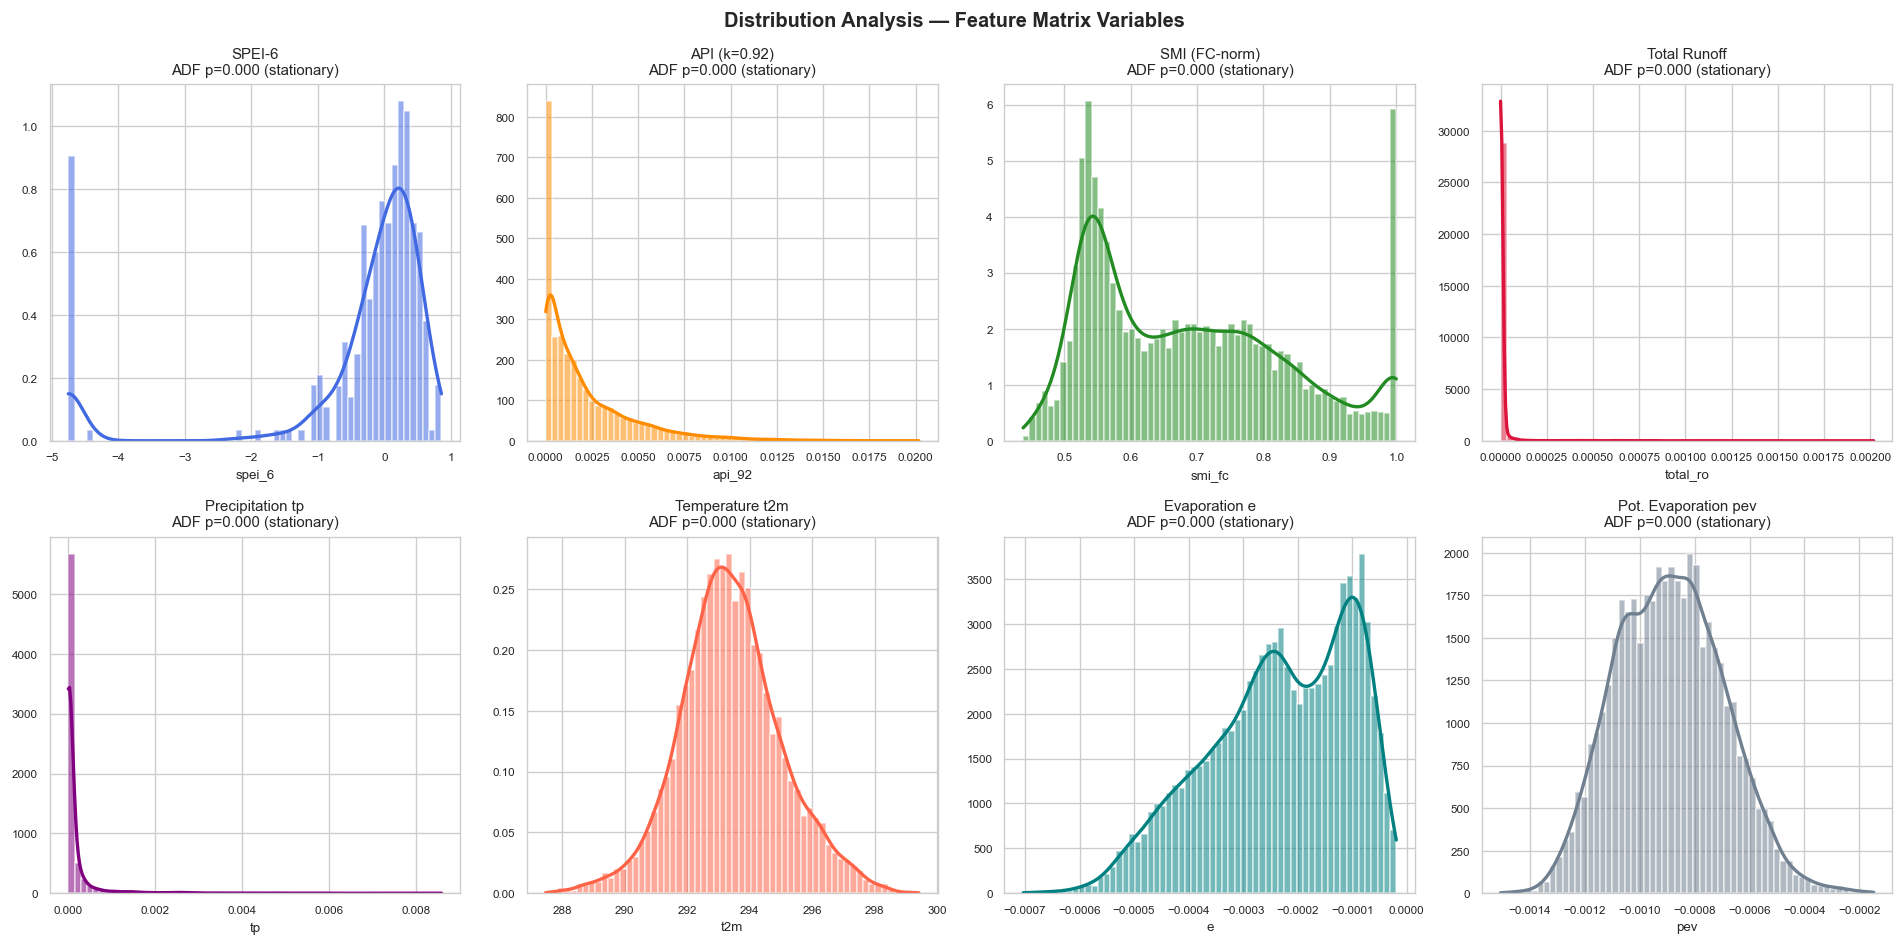

In [8]:
# ── P2: Distribution analysis — histograms + KDE + ADF stationarity test ──────
from scipy.stats import gaussian_kde

plot_vars = [
    ('spei_6',   'SPEI-6',          'royalblue'),
    ('api_92',   'API (k=0.92)',     'darkorange'),
    ('smi_fc',   'SMI (FC-norm)',    'forestgreen'),
    ('total_ro', 'Total Runoff',     'crimson'),
    ('tp',       'Precipitation tp', 'purple'),
    ('t2m',      'Temperature t2m',  'tomato'),
    ('e',        'Evaporation e',    'teal'),
    ('pev',      'Pot. Evaporation pev', 'slategray'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (col, label, color) in zip(axes.flat, plot_vars):
    data = df[col].dropna().values.astype(float)
    ax.hist(data, bins=60, color=color, alpha=0.55, density=True)
    kde = gaussian_kde(data)
    xr  = np.linspace(data.min(), data.max(), 300)
    ax.plot(xr, kde(xr), color=color, lw=2)
    adf_p = adfuller(data, maxlag=14, autolag=None)[1]
    ax.set_title(f'{label}\nADF p={adf_p:.3f} ({"stationary" if adf_p < 0.05 else "non-stationary"})',
                 fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('Distribution Analysis — Feature Matrix Variables', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('phase3_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Distribution Analysis - Feature Matrix Variables**

Each panel shows a histogram with a KDE overlay for the 8 variables that enter the feature matrix in Phase 4. The ADF p-value confirms all variables are stationary (p < 0.05), meaning no differencing is needed before using them as lag features.

- **SPEI-6**: Roughly bell-shaped, centred just below zero, with a longer left tail extending to −5. Reflects that dry conditions are more common than wet at this location.
- **API**: Strongly right-skewed: the vast majority of days are near zero, with a long tail from multi-day rain events. Most of the year is dry.
- **SMI**: Concentrated in the 0.5–1.0 range with a slight bimodal shape. Values below 0.5 are rare, suggesting root-zone soil moisture rarely drops critically low in absolute terms.
- **Total Runoff**: Almost entirely zero, with an extreme right tail of rare large spikes. Runoff is an exceptional event at this arid grid point.
- **Precipitation (tp)**: Similar to runoff: near-zero on most days, with a long right tail from rainfall events.
- **Temperature (t2m)**: Approximately normal, centred around 293 K (~20°C), reflecting a warm climate with moderate seasonal variation.
- **Evaporation (e)**: Negative values throughout (ERA5 convention: flux away from surface). Roughly bimodal, clustered around −0.0001 to −0.0003.
- **Potential Evaporation (pev)**: Also negative, bell-shaped and centred around −0.0008. The spread is wider than actual evaporation, reflecting that atmospheric demand varies more than actual water availability allows.


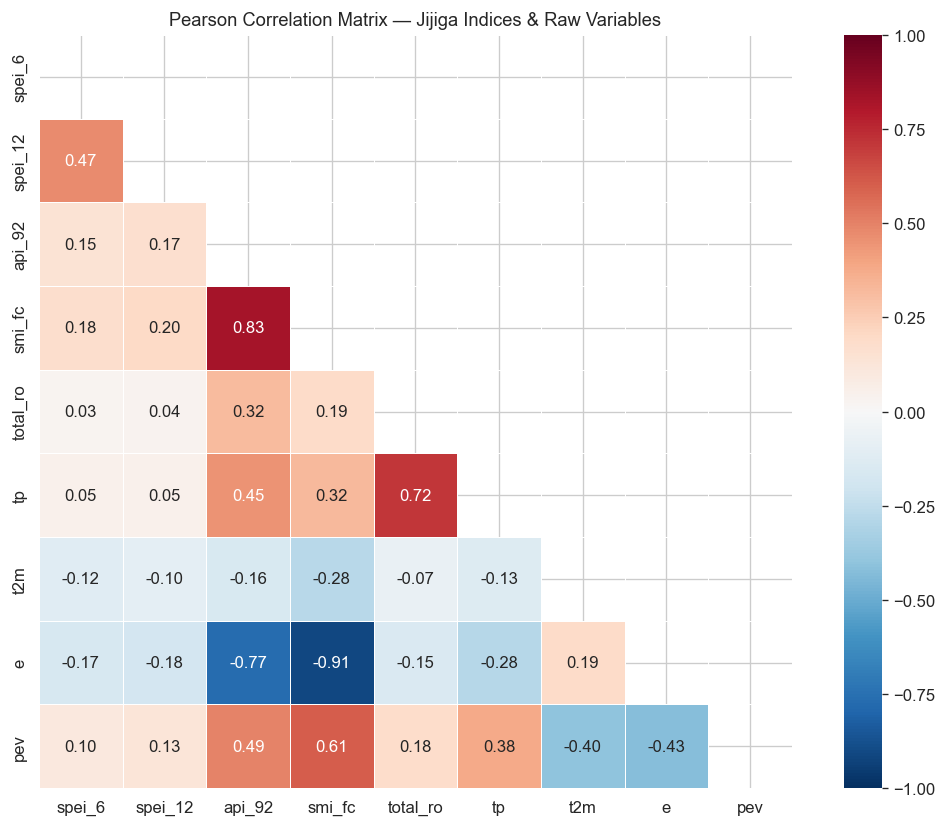

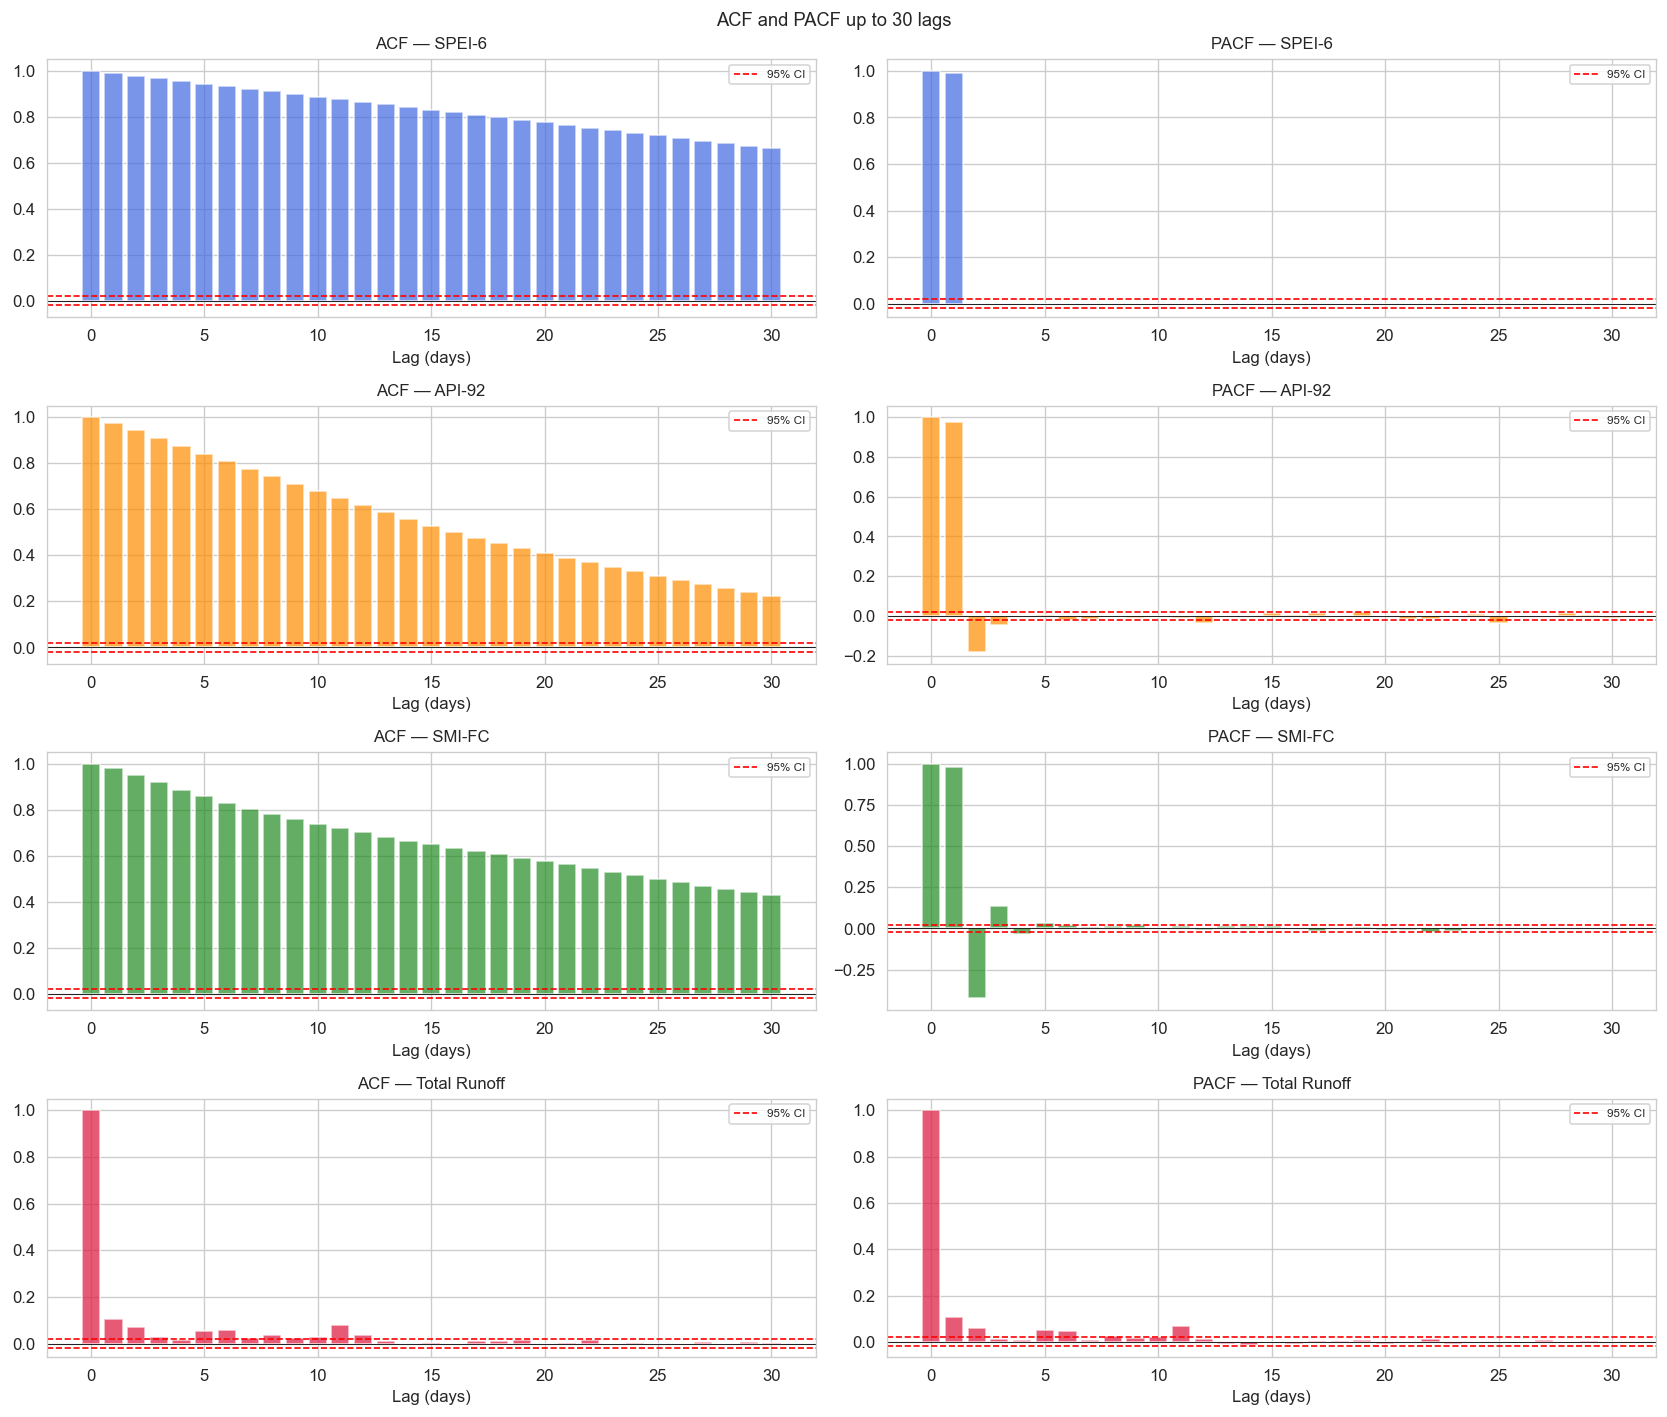

In [9]:
# ── P3: Correlation matrix + ACF/PACF (up to 30 lags) ────────────────────────
corr_cols = ['spei_6', 'spei_12', 'api_92', 'smi_fc', 'total_ro', 'tp', 't2m', 'e', 'pev']
corr = df[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation Matrix — Jijiga Indices & Raw Variables', fontsize=11)
plt.tight_layout()
plt.savefig('phase3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# ACF/PACF plots
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
acf_indices = [('spei_6','SPEI-6','royalblue'),('api_92','API-92','darkorange'),
               ('smi_fc','SMI-FC','forestgreen'),('total_ro','Total Runoff','crimson')]
for i, (col, label, color) in enumerate(acf_indices):
    series = df[col].dropna().values
    nlags  = 30
    acf_v  = acf(series,  nlags=nlags, fft=True)
    pacf_v = pacf(series, nlags=nlags)
    ci = 1.96 / np.sqrt(len(series))
    lags_x = np.arange(len(acf_v))
    for ax, vals, kind in zip(axes[i], [acf_v, pacf_v], ['ACF', 'PACF']):
        ax.bar(lags_x, vals, color=color, alpha=0.7)
        ax.axhline(0,   color='black', lw=0.5)
        ax.axhline( ci, color='red',   lw=1, ls='--', label='95% CI')
        ax.axhline(-ci, color='red',   lw=1, ls='--')
        ax.set_title(f'{kind} — {label}', fontsize=10)
        ax.set_xlabel('Lag (days)')
        ax.legend(fontsize=7)

plt.suptitle('ACF and PACF up to 30 lags', fontsize=11)
plt.tight_layout()
plt.savefig('phase3_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure (top) - Pearson Correlation Matrix.**

Key observations:

- **API and SMI (0.83)**: Strong positive correlation: both respond to the same rainfall events, one through accumulation history and the other through measured soil water content. They are not redundant however: API responds faster and decays quickly, while SMI integrates over both soil layers.
- **tp and total_ro (0.72)**: Strong positive - runoff is a direct consequence of intense precipitation exceeding soil absorption capacity.
- **e and SMI (−0.91)**: Very strong negative -  when soil is wet, actual evaporation increases (more negative in ERA5 convention). This is expected and confirms the physical consistency of the data.
- **e and API (−0.77)**: Same mechanism - high recent precipitation leads to both elevated API and more actual evaporation.
- **SPEI-6 and SPEI-12 (0.47)**: Moderate positive - both capture drought, but the lower correlation reflects that SPEI-12 smooths over shorter dry spells that SPEI-6 still picks up.
- **t2m and SMI (−0.28)**: Weak negative - warmer temperatures are associated with drier soils, consistent with the evaporative demand at this location.

Overall, the indices are sufficiently independent to each contribute distinct information to the feature matrix. No pair is so highly correlated that one could be dropped entirely.

**Figure (bottom) - ACF and PACF up to 30 lags**

The ACF (left) measures how correlated each variable is with its own past values. The PACF (right) isolates the direct effect of each lag after removing the influence of shorter lags. Red dashed lines mark the 95% significance threshold.

- **SPEI-6**: ACF decays very slowly, remaining above 0.6 at lag 30. SPEI-6 is highly persistent, meaning today's value is still strongly related to values two to four weeks ago. The PACF drops to near zero after lag 1, indicating a simple AR(1) structure: once you know yesterday's SPEI, no earlier lags add independent information. This justifies including lag-7 and lag-14 features for SPEI.
- **API**: ACF decays more gradually than SPEI, reaching ~0.2 by lag 30. The PACF shows a strong lag-1 spike with a small negative lag-2, reflecting the exponential decay built into the index. Memory fades faster than SPEI but still persists for 1–2 weeks.
- **SMI**: Similar to SPEI-6. Very slow ACF decay and a clean AR(1) PACF pattern. Soil moisture changes slowly and retains memory well beyond two weeks, making longer lags informative.
- **Total Runoff**: ACF drops to near zero almost immediately after lag 1, with only a few scattered significant values at longer lags. This confirms runoff has almost no memory. It is driven by individual events with no persistent carry-over. Lag-1 captures nearly all available signal.

Overall, the slow-moving indices (SPEI-6, SMI) justify including lag-7 and lag-14 features, while the event-driven variables (runoff, API) are best captured by shorter lags.


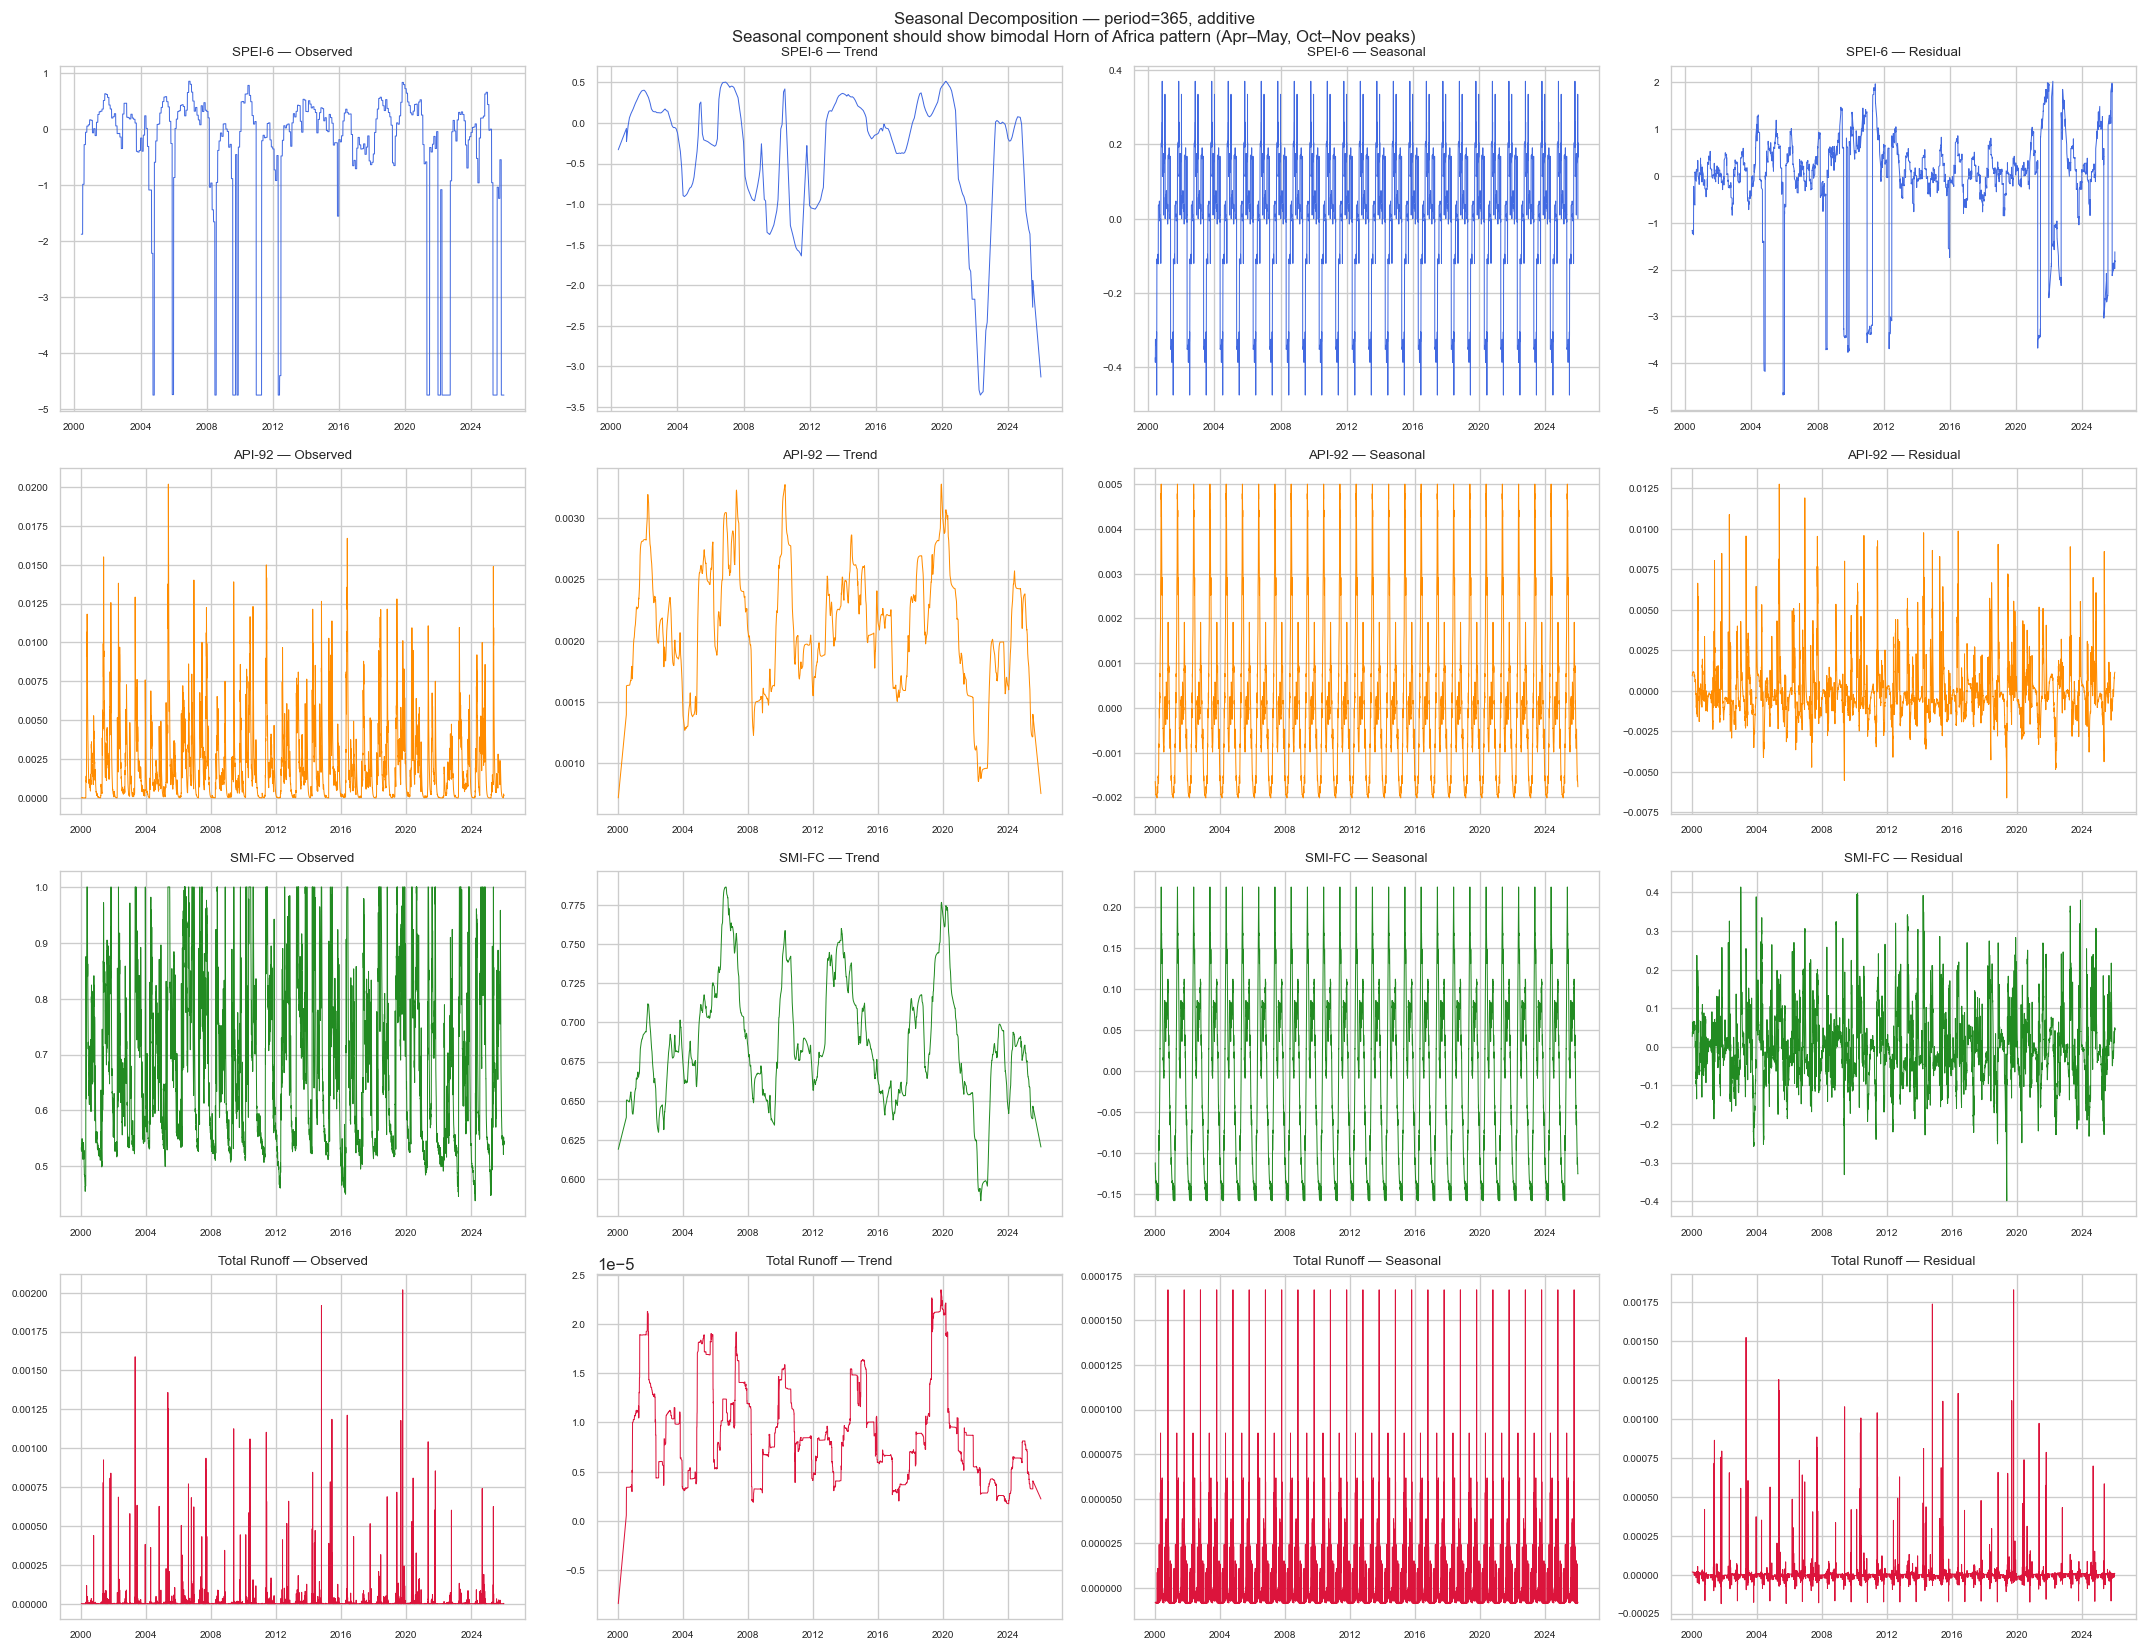

In [10]:
# ── P4: Seasonal decomposition — period=365 (additive model) ─────────────────
decomp_indices = [
    ('spei_6',   'SPEI-6',        'royalblue'),
    ('api_92',   'API-92',        'darkorange'),
    ('smi_fc',   'SMI-FC',        'forestgreen'),
    ('total_ro', 'Total Runoff',  'crimson'),
]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))

for row_i, (col, label, color) in enumerate(decomp_indices):
    series = df.set_index('time')[col].dropna().asfreq('D', method='ffill')
    result = seasonal_decompose(series, model='additive', period=365,
                                extrapolate_trend='freq')
    comps = [
        (result.observed,  'Observed'),
        (result.trend,     'Trend'),
        (result.seasonal,  'Seasonal'),
        (result.resid,     'Residual'),
    ]
    for col_j, (comp, cname) in enumerate(comps):
        ax = axes[row_i, col_j]
        ax.plot(comp.index, comp.values, color=color, lw=0.6)
        ax.set_title(f'{label} — {cname}', fontsize=8)
        ax.tick_params(labelsize=6)
        if row_i == 0 and cname == 'Trend':
            ax.set_xlabel('')

plt.suptitle('Seasonal Decomposition — period=365, additive\n'
             'Seasonal component should show bimodal Horn of Africa pattern (Apr–May, Oct–Nov peaks)',
             fontsize=10)
plt.tight_layout()
plt.savefig('phase3_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure - Seasonal decomposition (additive, period = 365 days)**

Each row shows one index broken into observed, trend, seasonal, and residual components.

**SPEI-6:**
- **Observed**: Fluctuates between −5 and +1, with sharp dips during dry seasons and major drought years.
- **Trend**: Captures multi-year variability. Notable dips around 2011 and 2020–2022, reflecting the worst drought periods.
- **Seasonal**: Stable bimodal pattern repeating every year, corresponding to the two dry seasons. Relatively small amplitude.
- **Residual**: Large spikes from exceptional drought events that fall outside the normal seasonal cycle:  these are the anomalies the model targets.


**API-92:**
- **Observed**: Near-zero most of the time with sharp spikes during rainfall events, reflecting the semi-arid baseline.
- **Trend**: Irregular fluctuations with notable increases around 2006 and 2018–2020, followed by a sharp drop, suggesting wetter-than-average periods before returning to drier conditions.
- **Seasonal**: Clear bimodal pattern aligned with the two rainy seasons (April–May, October–November).
- **Residual**: Dominated by individual intense rainfall events that fall outside the seasonal pattern.

**SMI-FC:**
- **Observed**: Oscillates between ~0.5 and 1.0, cycling with the rainy seasons. Never drops to zero, reflecting that this location retains some baseline soil moisture year-round.
- **Trend**: Irregular and volatile throughout the record, with multiple dips and recoveries rather than a clear directional pattern. No consistent long-term trend is visible.
- **Seasonal**: Consistent bimodal pattern matching the two rainy seasons, with amplitude of roughly ±0.15.
- **Residual**: Still shows notable swings (±0.3), meaning some years are significantly wetter or drier than the seasonal pattern predicts. This inter-annual variability is what the model learns to predict.

**Total Runoff:**
- **Observed**: Near-zero almost always, with occasional sharp spikes from intense rainfall events.
- **Trend**: Fluctuates irregularly at a very small scale (1e-5), with no clear direction. Slightly higher around 2018–2020.
- **Seasonal**: A very faint bimodal pattern is visible, but the amplitude is tiny, runoff is too event-driven for a meaningful seasonal signal.
- **Residual**: Almost identical to the observed signal, confirming that individual rainfall events dominate and neither trend nor seasonality explains much.



---
## Risk Label Construction

Training API 25th pct: 0.000244
Training SMI 25th pct: 0.5548

Drought risk class distribution:
  0 Low       : 79.8%
  1 Moderate  : 4.7%
  2 High      : 4.8%
  3 Extreme   : 10.7%

Flood score percentile thresholds (training 2000–2022):
  p65=0.2266  p80=0.3065  p90=0.4051

Flood risk class distribution:
  0 Low       : 65.1%
  1 Moderate  : 14.9%
  2 High      : 10.0%
  3 Extreme   : 10.0%


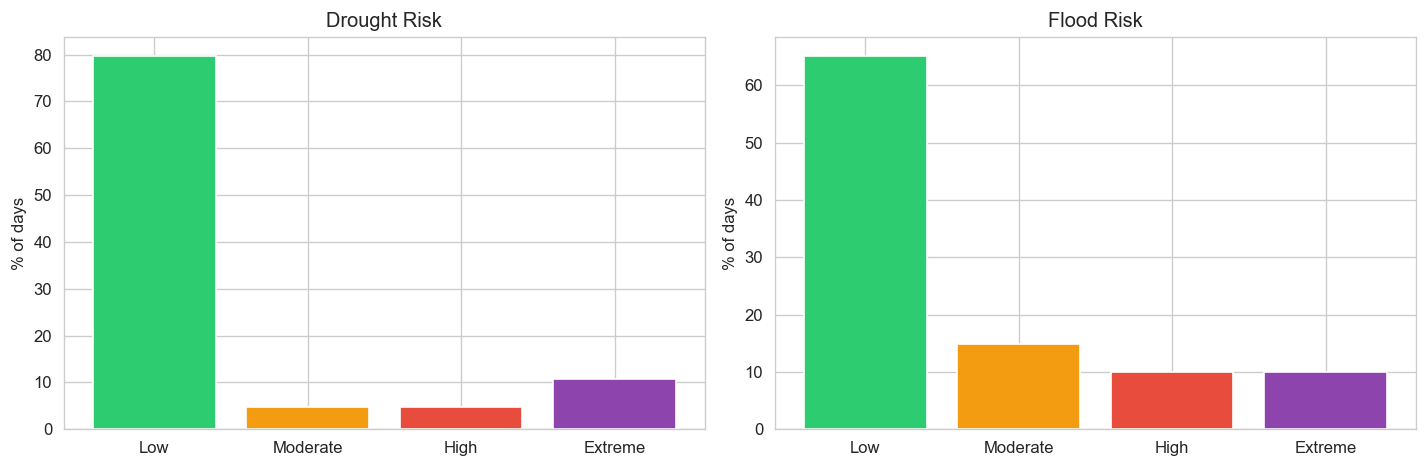

In [10]:
# ── Risk labels — Drought (SPEI-6 thresholds + modifier) & Flood (composite score)
train_mask = df['time'].dt.year <= TRAIN_END
label_map  = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Extreme'}
colors4    = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

# ── Drought ────────────────────────────────────────────────────────────────────
api_p25 = df.loc[train_mask, 'api_92'].quantile(0.25)
smi_p25 = df.loc[train_mask, 'smi_fc'].quantile(0.25)
print(f'Training API 25th pct: {api_p25:.6f}')
print(f'Training SMI 25th pct: {smi_p25:.4f}')

def spei_base_class(spei_val):
    if pd.isna(spei_val): return np.nan
    if spei_val >= -0.5:  return 0
    if spei_val >= -1.0:  return 1
    if spei_val >= -1.5:  return 2
    return 3

df['drought_base'] = df['spei_6'].map(spei_base_class)

def apply_modifier(row):
    base = row['drought_base']
    if pd.isna(base): return np.nan
    base = int(base)
    if base in (1, 2):
        if row['api_92'] < api_p25 or row['smi_fc'] < smi_p25:
            base = min(base + 1, 3)
    return base

df['drought_risk'] = df.apply(apply_modifier, axis=1)

dist_d = df['drought_risk'].value_counts(normalize=True).sort_index() * 100
print('\nDrought risk class distribution:')
for k, v in dist_d.items():
    print(f'  {int(k)} {label_map[int(k)]:10s}: {v:.1f}%')

# ── Flood ──────────────────────────────────────────────────────────────────────
for col in ['api_92', 'smi_fc', 'total_ro']:
    tr_min = df.loc[train_mask, col].min()
    tr_max = df.loc[train_mask, col].max()
    df[f'norm_{col}'] = ((df[col] - tr_min) / (tr_max - tr_min + 1e-12)).clip(0, 1)

df['flood_score'] = (0.40 * df['norm_api_92'] +
                     0.35 * df['norm_smi_fc']  +
                     0.25 * df['norm_total_ro'])

tr_scores = df.loc[train_mask, 'flood_score']
p65, p80, p90 = (tr_scores.quantile(q) for q in [0.65, 0.80, 0.90])
print(f'\nFlood score percentile thresholds (training 2000–{TRAIN_END}):')
print(f'  p65={p65:.4f}  p80={p80:.4f}  p90={p90:.4f}')

def flood_label(score):
    if pd.isna(score): return np.nan
    if score < p65: return 0
    if score < p80: return 1
    if score < p90: return 2
    return 3

df['flood_risk'] = df['flood_score'].map(flood_label)

dist_f = df['flood_risk'].value_counts(normalize=True).sort_index() * 100
print('\nFlood risk class distribution:')
for k, v in dist_f.items():
    print(f'  {int(k)} {label_map[int(k)]:10s}: {v:.1f}%')

# ── Side-by-side plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, dist_, title in zip(axes, [dist_d, dist_f], ['Drought Risk', 'Flood Risk']):
    ax.bar([label_map[k] for k in sorted(dist_.index)],
           [dist_[k] for k in sorted(dist_.index)], color=colors4)
    ax.set_ylabel('% of days')
    ax.set_title(title)
plt.tight_layout()
plt.savefig('phase3_risk_classes.png', dpi=150, bbox_inches='tight')
plt.show()


**Figure - Drought Risk Class Distribution**

The distribution is heavily dominated by Low risk (~79.8%), which is expected for a semi-arid location where drought conditions are the exception rather than the norm. Moderate and High together account for less than 10% of days. The modifier rule takes days that are already Moderate or High drought risk (based on SPEI) and bumps them up one level if the soil is also dry, meaning API or SMI is in the bottom 25% of historical values. So a Moderate day can become High, and a High day can become Extreme. This means days pile up at Extreme more than you'd expect, because it receives the "overflow" from both Moderate and High days whenever dry soil conditions coincide with low SPEI.

**Figure - Flood Risk Class Distribution**

Flood risk is more evenly spread than drought risk. Low accounts for ~65%, with Moderate (15%), High (10%), and Extreme (10%) each taking a meaningful share. The class boundaries are set by percentile thresholds from the training data (p65, p80, p90), so the split is by design rather than driven by physical thresholds like SPEI. High and Extreme are equal at 10% each, reflecting that the top 20% of flood score days are split evenly between the two upper classes.


In [13]:
# ── P3: Shifted target columns for all 8 forecast tasks ──────────────────────
horizons = [1, 3, 7, 14]
for n in horizons:
    df[f'drought_risk_t_plus_{n}'] = df['drought_risk'].shift(-n)
    df[f'flood_risk_t_plus_{n}']   = df['flood_risk'].shift(-n)

# Manual spot-check (3 random dates)
np.random.seed(0)
sample_idx = np.random.randint(100, len(df) - 14, 3)
print('Shifted target spot-checks:')
for idx in sample_idx:
    date = df.loc[idx, 'time']
    target_val = df.loc[idx, 'drought_risk_t_plus_7']
    actual_val = df.loc[idx + 7, 'drought_risk']
    match = 'OK' if target_val == actual_val or (pd.isna(target_val) and pd.isna(actual_val)) else 'FAIL'
    print(f'  {date.date()} drought_risk_t+7={target_val}  drought_risk({(date + pd.Timedelta(7,"D")).date()})={actual_val}  [{match}]')

print(f'\nTarget columns created: {[c for c in df.columns if "t_plus" in c]}')
print(f'NaNs in each target (last {14} rows expected):')
for c in [c for c in df.columns if 't_plus' in c]:
    print(f'  {c}: {df[c].isna().sum()} NaN rows')

Shifted target spot-checks:
  2007-10-03 drought_risk_t+7=0.0  drought_risk(2007-10-10)=0.0  [OK]
  2009-03-18 drought_risk_t+7=0.0  drought_risk(2009-03-25)=0.0  [OK]
  2013-07-30 drought_risk_t+7=0.0  drought_risk(2013-08-06)=0.0  [OK]

Target columns created: ['drought_risk_t_plus_1', 'flood_risk_t_plus_1', 'drought_risk_t_plus_3', 'flood_risk_t_plus_3', 'drought_risk_t_plus_7', 'flood_risk_t_plus_7', 'drought_risk_t_plus_14', 'flood_risk_t_plus_14']
NaNs in each target (last 14 rows expected):
  drought_risk_t_plus_1: 152 NaN rows
  flood_risk_t_plus_1: 1 NaN rows
  drought_risk_t_plus_3: 152 NaN rows
  flood_risk_t_plus_3: 3 NaN rows
  drought_risk_t_plus_7: 152 NaN rows
  flood_risk_t_plus_7: 7 NaN rows
  drought_risk_t_plus_14: 152 NaN rows
  flood_risk_t_plus_14: 14 NaN rows


**Shifted target columns**

To train a model that predicts risk *n* days into the future, the target column needs to contain the risk value that actually occurs *n* days later. This is done by shifting the risk columns backwards by n rows, so that on any given day, the model sees today's features alongside the label from n days ahead.

Four horizons are created for both drought and flood risk: +1, +3, +7, and +14 days, giving 8 target columns in total. The spot-check confirms the shift is correct by verifying that the value in `drought_risk_t_plus_7` on a given date matches `drought_risk` exactly 7 days later.

The last n rows of each target column become NaN, since there is no future data to shift into them.


In [14]:
# ── P4: Class distribution across all 8 targets + EMDAT spot validation ───────
target_cols = ([f'drought_risk_t_plus_{n}' for n in horizons] +
               [f'flood_risk_t_plus_{n}'   for n in horizons])

print('Class distributions for all 8 forecast targets:')
print(f'{"Task":<30} {"Low%":>6} {"Mod%":>6} {"High%":>6} {"Ext%":>6}')
print('-' * 55)
for col in target_cols:
    d = df[col].value_counts(normalize=True).sort_index() * 100
    vals = [d.get(k, 0) for k in range(4)]
    print(f'{col:<30} {vals[0]:>6.1f} {vals[1]:>6.1f} {vals[2]:>6.1f} {vals[3]:>6.1f}')

# EMDAT spot validation: every major event should reach ≥ Moderate flood risk
print('\nEMDAT Flood Event Spot Check (Ethiopia):')
print(f'{"Year-Month":<12} {"MaxFloodRisk":<15} {"Location"}')
print('-' * 60)
for _, row in eth_flood.sort_values('Start Year').iterrows():
    yr = int(row['Start Year'])
    mo = int(row.get('Start Month') or 1)
    end_date = row['end_date'] if pd.notna(row['end_date']) else row['start_date'] + pd.Timedelta(30, 'D')
    window = df[(df['time'] >= row['start_date'] - pd.Timedelta(30, 'D')) &
                (df['time'] <= end_date + pd.Timedelta(30, 'D'))]
    max_risk = int(window['flood_risk'].max()) if len(window) else -1
    flag = '⚠' if max_risk < 1 else ''
    loc  = str(row.get('Location', ''))[:35]
    print(f'{yr}-{mo:02d}       {max_risk}  {label_map.get(max_risk,"?")}  {flag}  {loc}')

Class distributions for all 8 forecast targets:
Task                             Low%   Mod%  High%   Ext%
-------------------------------------------------------
drought_risk_t_plus_1            79.8    4.7    4.8   10.7
drought_risk_t_plus_3            79.8    4.7    4.8   10.7
drought_risk_t_plus_7            79.8    4.7    4.8   10.7
drought_risk_t_plus_14           79.8    4.7    4.8   10.7
flood_risk_t_plus_1              65.1   14.9   10.0   10.0
flood_risk_t_plus_3              65.1   14.9   10.0   10.0
flood_risk_t_plus_7              65.1   14.9   10.0   10.0
flood_risk_t_plus_14             65.1   14.9   10.0   10.0

EMDAT Flood Event Spot Check (Ethiopia):
Year-Month   MaxFloodRisk    Location
------------------------------------------------------------
2000-08       2  High    Dubti area (Zone 1 district, Afar p
2000-06       1  Moderate    Nazareth city (East Shewa district,
2001-08       2  High    Dubti, Asaita areas (Zone 1 distric
2002-04       3  Extreme    Afar, Oro

In [15]:
# ── Save labeled dataset ──────────────────────────────────────────────────────
drop_tmp = ['drought_base', 'norm_api_92', 'norm_smi_fc', 'norm_total_ro', 'flood_score']
df_out = df.drop(columns=[c for c in drop_tmp if c in df.columns])

df_out.to_parquet(OUT_PATH, index=False)
print(f'Saved: {OUT_PATH}')
print(f'Shape: {df_out.shape}')
print('New columns:', [c for c in df_out.columns if c not in
       pd.read_parquet(DATA_PATH).columns.tolist()])

Saved: ../src/data/processed/era5_labeled.parquet
Shape: (9497, 34)
New columns: ['drought_risk', 'flood_risk', 'drought_risk_t_plus_1', 'flood_risk_t_plus_1', 'drought_risk_t_plus_3', 'flood_risk_t_plus_3', 'drought_risk_t_plus_7', 'flood_risk_t_plus_7', 'drought_risk_t_plus_14', 'flood_risk_t_plus_14']
